# **Cybersecurity Network Traffic Dataset: EDA**

This dataset contains **network traffic records used for cybersecurity analysis**, specifically focused on detecting **Distributed Denial of Service (DDoS) and network flooding attacks**.  
Each CSV file represents traffic captured during a **specific attack type or normal network behavior**.


The dataset is divided into multiple CSV files, each corresponding to a specific attack category or normal traffic type.

| File | Description |
|-----|-------------|
| `DrDoS_DNS.csv` | DNS amplification Distributed Reflection Denial of Service attack traffic |
| `DrDoS_LDAP.csv` | LDAP reflection DDoS attack traffic |
| `DrDoS_MSSQL.csv` | MSSQL reflection DDoS attack traffic |
| `DrDoS_NetBIOS.csv` | NetBIOS reflection DDoS attack traffic |
| `DrDoS_NTP.csv` | NTP amplification attack traffic |
| `DrDoS_SNMP.csv` | SNMP reflection DDoS attack traffic |
| `DrDoS_SSDP.csv` | SSDP reflection DDoS attack traffic |
| `DrDoS_UDP.csv` | UDP flood distributed denial of service traffic |
| `Syn.csv` | SYN flood attack traffic |

These attack types are examples of volumetric or reflection-based DDoS attacks, where attackers overwhelm a server or network by generating massive traffic.



In [1]:
print("Hello World")

Hello World


### **00 Libraries**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

### **01 Load Dataset**

For training, we only consider the following CSV files due to limited computational resources. These CSV files were selected because these traffic types are commonly associated with reflection and amplification attacks. In these attacks, the attacker sends spoofed requests to legitimate servers (such as DNS, LDAP, or NTP services). The source IP address is forged to appear as the victim's address. As a result, the legitimate server sends the response to the victim instead of the attacker. Therefore, the analysis will focus on the following datasets:

- **DNS.csv**
- **LDAP.csv**
- **NTP.csv**
- **Syn.csv**


In [3]:
PATH = "CSV-01-12/01-12/"
OUTPUT_PATH = "clean_data/"

In [4]:
FILES_0112 = [
    "DrDoS_DNS.csv",
    "DrDoS_LDAP.csv",
    "DrDoS_NTP.csv",
    "Syn.csv"
]

# Cleaned dataset filenames
FILES_0112_CLEAN = [
    "DrDoS_DNS_clean.csv",
    "DrDoS_LDAP_clean.csv",
    "DrDoS_NTP_clean.csv",
    "Syn_clean.csv",
]



In [7]:
def load_datasets(filenames: list[str], directory: str) -> dict[str, pd.DataFrame]:
    
    dfs = {}

    for file in filenames:
        path = directory + file
        df = pd.read_csv(path)

        # Clean column names
        df.columns = df.columns.str.strip()

        dfs[file] = df

        print(f"{file} -> Loaded")
        print(f"  Shape: {df.shape}")

        if "Label" in df.columns:
            print("  Label distribution:")
            print(df["Label"].value_counts())
        else:
            print("  WARNING: 'Label' column not found")
            print("  Columns:", df.columns.tolist())

        print("-" * 40)

    return dfs

In [8]:
dfs = load_datasets(FILES_0112, PATH)

C:\Users\Ale\AppData\Local\Temp\ipykernel_21344\2501552088.py:7: DtypeWarning: Columns (85) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


DrDoS_DNS.csv -> Loaded
  Shape: (5074413, 88)
  Label distribution:
Label
DrDoS_DNS    5071011
BENIGN          3402
Name: count, dtype: int64
----------------------------------------


C:\Users\Ale\AppData\Local\Temp\ipykernel_21344\2501552088.py:7: DtypeWarning: Columns (85) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


DrDoS_LDAP.csv -> Loaded
  Shape: (2181542, 88)
  Label distribution:
Label
DrDoS_LDAP    2179930
BENIGN           1612
Name: count, dtype: int64
----------------------------------------


C:\Users\Ale\AppData\Local\Temp\ipykernel_21344\2501552088.py:7: DtypeWarning: Columns (85) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


DrDoS_NTP.csv -> Loaded
  Shape: (1217007, 88)
  Label distribution:
Label
DrDoS_NTP    1202642
BENIGN         14365
Name: count, dtype: int64
----------------------------------------


C:\Users\Ale\AppData\Local\Temp\ipykernel_21344\2501552088.py:7: DtypeWarning: Columns (85) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


Syn.csv -> Loaded
  Shape: (1582681, 88)
  Label distribution:
Label
Syn       1582289
BENIGN        392
Name: count, dtype: int64
----------------------------------------


# **1. EDA**

### **1.1 Distribution Analysis**

The dataset is extremely imbalanced. Therefore, it requires either undersampling or oversampling techniques. 
Since the dataset is very large, we will apply **undersampling** to the **Attack** class in order to balance the class distribution.

In [16]:
def plot_distribution(dfs: dict[str, pd.DataFrame]) -> None:
    sns.set_theme(style="white")
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()

    for i, (filename, df) in enumerate(dfs.items()):
        ax = axes[i]
        counts = df['Label'].value_counts()
        colors = []
        for label in counts.index:
            if "BENIGN" in label:
                colors.append("#a6d8ff")  
            else:
                colors.append("#f3a6e3") 

        bars = sns.barplot(x=counts.index, y=counts.values,hue= counts.index, ax=ax, palette=colors, legend=False)

        ax.set_facecolor("#fde7f6")

        for j, value in enumerate(counts.values):
            ax.text(j, value, f"{value:,}", ha='center', va='bottom', fontsize=10, fontweight='bold')

        title = filename.replace(".csv", "")
        ax.set_title(title, fontsize=12)

        ax.set_xlabel("Traffic Type")
        ax.set_ylabel("Count")

    plt.tight_layout()
    plt.show()
    return None

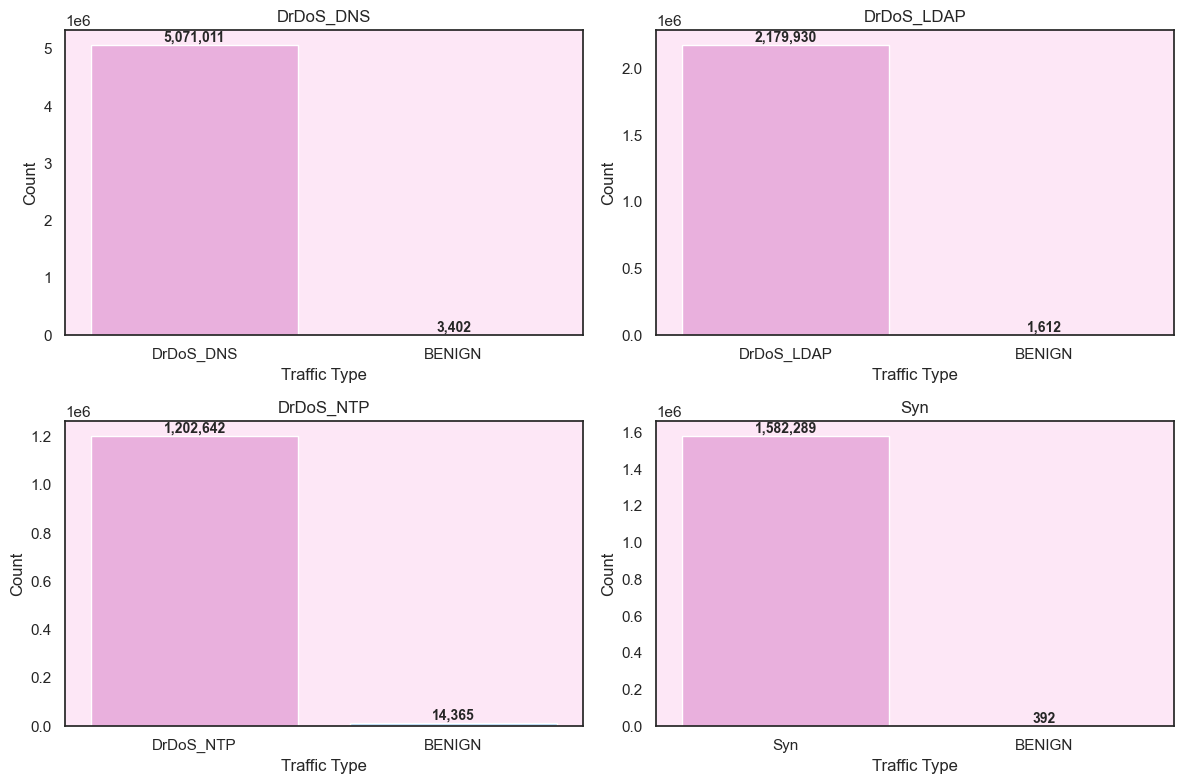

In [17]:
plot_distribution(dfs)

### **1.2 Null and Invalid Values**

We will check whether there are **null values** in the dataset and determine how they should be handled.

Additionally, we identified the presence of **infinite values (`inf`)**. These values typically appear when a mathematical operation results in a number that exceeds the representable range, such as division by zero or extremely large calculations. In network traffic datasets, this can occur when certain derived metrics involve ratios where the denominator is zero.

It is important to detect these invalid values because they can negatively affect statistical analysis and deep learning models.


In [18]:
def count_nan_values(dfs: dict[str, pd.DataFrame]) -> None:
    nan_counts = {}

    for name, df in dfs.items():
        nan_count = df.isna().sum().sum()
        nan_counts[name] = nan_count
        print(f"{name} -> NaN values: {nan_count}")

    return None

In [19]:
def count_inf_values(dfs: dict[str, pd.DataFrame]) -> None:
    inf_counts = {}

    for name, df in dfs.items():
        numeric_df = df.select_dtypes(include=[np.number])
        inf_count = np.isinf(numeric_df).sum().sum()
        inf_counts[name] = inf_count
        print(f"{name} -> INF values: {inf_count}")

    return None

In [20]:
print("\n" + "=" * 40)
print("TOTAL INF VALUES")
print("=" * 40)
count_inf_values(dfs)

print("\n" + "=" * 40)
print("TOTAL NaN VALUES")
print("=" * 40)
count_nan_values(dfs)


TOTAL INF VALUES
DrDoS_DNS.csv -> INF values: 324757
DrDoS_LDAP.csv -> INF values: 77288
DrDoS_NTP.csv -> INF values: 14061
Syn.csv -> INF values: 202357

TOTAL NaN VALUES
DrDoS_DNS.csv -> NaN values: 31
DrDoS_LDAP.csv -> NaN values: 12
DrDoS_NTP.csv -> NaN values: 31
Syn.csv -> NaN values: 202277



Therefore, we must evaluate whether it is necessary to **remove affected samples** or **drop specific columns** in order to prevent data corruption or significant information loss.

In [21]:
def inf_columns(dfs: dict[str, pd.DataFrame]) -> None:
    result = {}

    for name, df in dfs.items():
        numeric_df = df.select_dtypes(include=[np.number])
        inf_per_col = np.isinf(numeric_df).sum()
        inf_per_col = inf_per_col[inf_per_col > 0]
        result[name] = inf_per_col

        print(f"\n{name} -> INF columns:")
        print(inf_per_col if not inf_per_col.empty else "  None")

    return None


def nan_columns(dfs: dict[str, pd.DataFrame]) -> None:
    result = {}

    for name, df in dfs.items():
        nan_per_col = df.isna().sum()
        nan_per_col = nan_per_col[nan_per_col > 0]
        result[name] = nan_per_col

        print(f"\n{name} -> NaN columns:")
        print(nan_per_col if not nan_per_col.empty else "  None")

    return None

In [22]:
print("\n" + "=" * 40)
print("INF COLUMNS (per dataset)")
print("=" * 40)
inf_columns(dfs)

print("\n" + "=" * 40)
print("NaN COLUMNS (per dataset)")
print("=" * 40)
nan_columns(dfs)


INF COLUMNS (per dataset)

DrDoS_DNS.csv -> INF columns:
Flow Bytes/s      162363
Flow Packets/s    162394
dtype: int64

DrDoS_LDAP.csv -> INF columns:
Flow Bytes/s      38638
Flow Packets/s    38650
dtype: int64

DrDoS_NTP.csv -> INF columns:
Flow Bytes/s      7015
Flow Packets/s    7046
dtype: int64

Syn.csv -> INF columns:
Flow Bytes/s          40
Flow Packets/s    202317
dtype: int64

NaN COLUMNS (per dataset)

DrDoS_DNS.csv -> NaN columns:
Flow Bytes/s    31
dtype: int64

DrDoS_LDAP.csv -> NaN columns:
Flow Bytes/s    12
dtype: int64

DrDoS_NTP.csv -> NaN columns:
Flow Bytes/s    31
dtype: int64

Syn.csv -> NaN columns:
Flow Bytes/s    202277
dtype: int64


It is important to determine the **percentage of invalid data** before deciding which preprocessing techniques to apply.  

Evaluating the proportion of missing or invalid values allows us to choose appropriate strategies, such as **removing samples**, **dropping columns**, or **applying imputation methods**, while minimizing unnecessary information loss.It is imnportant to check how much percentage of data is invalid before deciding preproceessing technqies

In [23]:
def data_quality_summary(dfs: dict[str, pd.DataFrame]) -> pd.DataFrame:
    records = []

    for name, df in dfs.items():
        total_cells = df.shape[0] * df.shape[1]
        numeric_df = df.select_dtypes(include=[np.number])

        inf_count = np.isinf(numeric_df).sum().sum()
        nan_count = df.isna().sum().sum()

        inf_pct = inf_count / total_cells
        nan_pct = nan_count / total_cells

        records.append({"dataset": name, "inf_pct": inf_pct, "nan_pct": nan_pct})

        print(f"{name}")
        print(f"  INF %: {inf_pct:.6f}")
        print(f"  NaN %: {nan_pct:.6f}")
        print("-" * 40)

    return pd.DataFrame(records)

In [24]:
print("\n" + "=" * 40)
print("DATA QUALITY SUMMARY (%)")
print("=" * 40)
summary_df = data_quality_summary(dfs)


DATA QUALITY SUMMARY (%)
DrDoS_DNS.csv
  INF %: 0.000727
  NaN %: 0.000000
----------------------------------------
DrDoS_LDAP.csv
  INF %: 0.000403
  NaN %: 0.000000
----------------------------------------
DrDoS_NTP.csv
  INF %: 0.000131
  NaN %: 0.000000
----------------------------------------
Syn.csv
  INF %: 0.001453
  NaN %: 0.001452
----------------------------------------


The analysis of data quality shows that the percentage of invalid values in the datasets is extremely low.

| Dataset | INF (%) | NaN (%) |
|-------|-------|-------|
| DrDoS_DNS.csv | 0.000727 | 0.000000 |
| DrDoS_LDAP.csv | 0.000403 | 0.000000 |
| DrDoS_NTP.csv | 0.000131 | 0.000000 |
| Syn.csv | 0.001453 | 0.001452 |

Since the proportion of infinite (`inf`) and missing (`NaN`) values is very close to zero, their presence represents only a negligible fraction of the dataset. Therefore, the most appropriate preprocessing strategy is to **remove the affected samples**, as this will not significantly impact the dataset size or the statistical properties of the data while ensuring cleaner inputs for subsequent analysis and model training.

In [25]:
def clean_dfs(dfs: dict[str, pd.DataFrame]) -> dict[str, pd.DataFrame]:

    cleaned_dfs = {}

    for name, df in dfs.items():
        print(f"Cleaning {name}...")

        df = df.copy()

        # remove whitespace from column names
        df.columns = df.columns.str.strip()

        # replace infinite values
        df.replace([np.inf, -np.inf], np.nan, inplace=True)

        # drop rows with NaN
        df.dropna(inplace=True)

        cleaned_dfs[name] = df

    print("-" * 40)
    print("Cleaning completed.")

    return cleaned_dfs

In [26]:
dfs = clean_dfs(dfs)

Cleaning DrDoS_DNS.csv...
Cleaning DrDoS_LDAP.csv...
Cleaning DrDoS_NTP.csv...
Cleaning Syn.csv...
----------------------------------------
Cleaning completed.


To handle invalid numerical values, the preprocessing pipeline will first **convert `inf` and `-inf` values into `NaN`**, allowing them to be treated as missing data. 

After this transformation, the pipeline will apply **`dropna()`** to remove the affected samples. Given that the proportion of invalid values is extremely small, this approach ensures data consistency while preserving the overall integrity of the dataset.

### **1.3 Constant Columns**

Constant columns are features that contain **only one possible value for all samples** in the dataset.  
Because these columns do not vary across observations, they **do not provide any useful information** for the training process.

Machine learning models learn patterns by analyzing how feature values change across different samples.  
If a column always contains the same value, it has **zero variance** and therefore **cannot help distinguish between classes**.

For this reason, columns with **only one unique value** were identified and removed from the dataset.  
This step helps reduce unnecessary dimensionality and improves the efficiency of the training process without affecting the predictive information available to the model.

In [27]:
def drop_constant_columns(dfs: dict[str, pd.DataFrame]) -> dict[str, pd.DataFrame]:
    
    constant_per_dataset = {}

    for name, df in dfs.items():
        constant_cols = set(df.columns[df.nunique() == 1])
        constant_per_dataset[name] = constant_cols
    common_constant = set.intersection(*constant_per_dataset.values())

    print("Columns constant in every dataset:")
    print(common_constant)

    # drop them
    for name, df in dfs.items():
        dfs[name] = df.drop(columns=common_constant)

    return dfs

In [28]:
dfs = drop_constant_columns(dfs)

Columns constant in every dataset:
{'PSH Flag Count', 'Fwd Avg Bytes/Bulk', 'Fwd URG Flags', 'FIN Flag Count', 'ECE Flag Count', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bulk Rate', 'Bwd PSH Flags', 'Bwd URG Flags'}


### **1.4 Feature Types**

In [29]:
for name, df in dfs.items():
    print("="*50)
    print(name)
    print(df.dtypes)

DrDoS_DNS.csv
Unnamed: 0          int64
Flow ID            object
Source IP          object
Source Port         int64
Destination IP     object
                   ...   
Idle Max          float64
Idle Min          float64
SimillarHTTP       object
Inbound             int64
Label              object
Length: 76, dtype: object
DrDoS_LDAP.csv
Unnamed: 0          int64
Flow ID            object
Source IP          object
Source Port         int64
Destination IP     object
                   ...   
Idle Max          float64
Idle Min          float64
SimillarHTTP       object
Inbound             int64
Label              object
Length: 76, dtype: object
DrDoS_NTP.csv
Unnamed: 0          int64
Flow ID            object
Source IP          object
Source Port         int64
Destination IP     object
                   ...   
Idle Max          float64
Idle Min          float64
SimillarHTTP       object
Inbound             int64
Label              object
Length: 76, dtype: object
Syn.csv
Unnamed: 0   

In [30]:
for name, df in dfs.items():
    print("="*50)
    print(name)
    print("Shape:", df.shape)
    print(df.head(3))

DrDoS_DNS.csv
Shape: (4912019, 76)
   Unnamed: 0                               Flow ID     Source IP  \
0         425  172.16.0.5-192.168.50.1-634-60495-17    172.16.0.5   
1         430  172.16.0.5-192.168.50.1-60495-634-17  192.168.50.1   
2        1654  172.16.0.5-192.168.50.1-634-46391-17    172.16.0.5   

   Source Port Destination IP  Destination Port  Protocol  \
0          634   192.168.50.1             60495        17   
1          634     172.16.0.5             60495        17   
2          634   192.168.50.1             46391        17   

                    Timestamp  Flow Duration  Total Fwd Packets  ...  \
0  2018-12-01 10:51:39.813448          28415                 97  ...   
1  2018-12-01 10:51:39.820842              2                  2  ...   
2  2018-12-01 10:51:39.852499          48549                200  ...   

   Active Std  Active Max  Active Min  Idle Mean  Idle Std  Idle Max  \
0         0.0         0.0         0.0        0.0       0.0       0.0   
1         

### **1.5 Non-Numerical Features**

The dataset contains several columns that are **not numerical** and therefore require special consideration during preprocessing. Most machine learning models require **numerical inputs**, therefore these columns must be handled appropriately during preprocessing.



In [31]:
for name, df in dfs.items():
    print("="*50)
    print(name)

    non_numeric = df.select_dtypes(exclude='number')
    print(non_numeric.dtypes)

DrDoS_DNS.csv
Flow ID           object
Source IP         object
Destination IP    object
Timestamp         object
SimillarHTTP      object
Label             object
dtype: object
DrDoS_LDAP.csv
Flow ID           object
Source IP         object
Destination IP    object
Timestamp         object
SimillarHTTP      object
Label             object
dtype: object
DrDoS_NTP.csv
Flow ID           object
Source IP         object
Destination IP    object
Timestamp         object
SimillarHTTP      object
Label             object
dtype: object
Syn.csv
Flow ID           object
Source IP         object
Destination IP    object
Timestamp         object
SimillarHTTP      object
Label             object
dtype: object


| Column | Data Type | Description |
|------|------|------|
| `Flow ID` | object | Unique identifier for each network flow |
| `Source IP` | object | IP address of the source host |
| `Destination IP` | object | IP address of the destination host |
| `Timestamp` | object | Time at which the network flow was recorded |
| `SimillarHTTP` | object | HTTP-related metadata extracted from the flow |
| `Label` | object | Target variable indicating whether the traffic is **benign or malicious** |



Some of these variables, such as **Flow ID, Source IP, and Destination IP**, primarily act as identifiers and may not contribute meaningful information for prediction. Others, like **Timestamp**, could potentially be transformed into useful temporal features if needed. The **Label** column represents the target variable used for classification.

In [32]:
def preprocess_datasets(datasets: dict) -> dict:
    columns_to_drop = [
        "Flow ID",
        "Source IP",
        "Destination IP",
        "Timestamp",
        "SimillarHTTP"
    ]
    
    processed = {}

    for name, df in datasets.items():
        
        df = df.copy()
        df = df.drop(columns=[c for c in columns_to_drop if c in df.columns], errors="ignore")

        # Convert Label: Benign -> 0, others -> 1
        if "Label" in df.columns:
            df["Label"] = (df["Label"] != "BENIGN").astype(int)

        processed[name] = df

    return processed

In [33]:
dfs = preprocess_datasets(dfs)

### **1.6 Histograms**

c:\Users\Ale\Documents\NN-Labs\.venv\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\Ale\Documents\NN-Labs\.venv\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


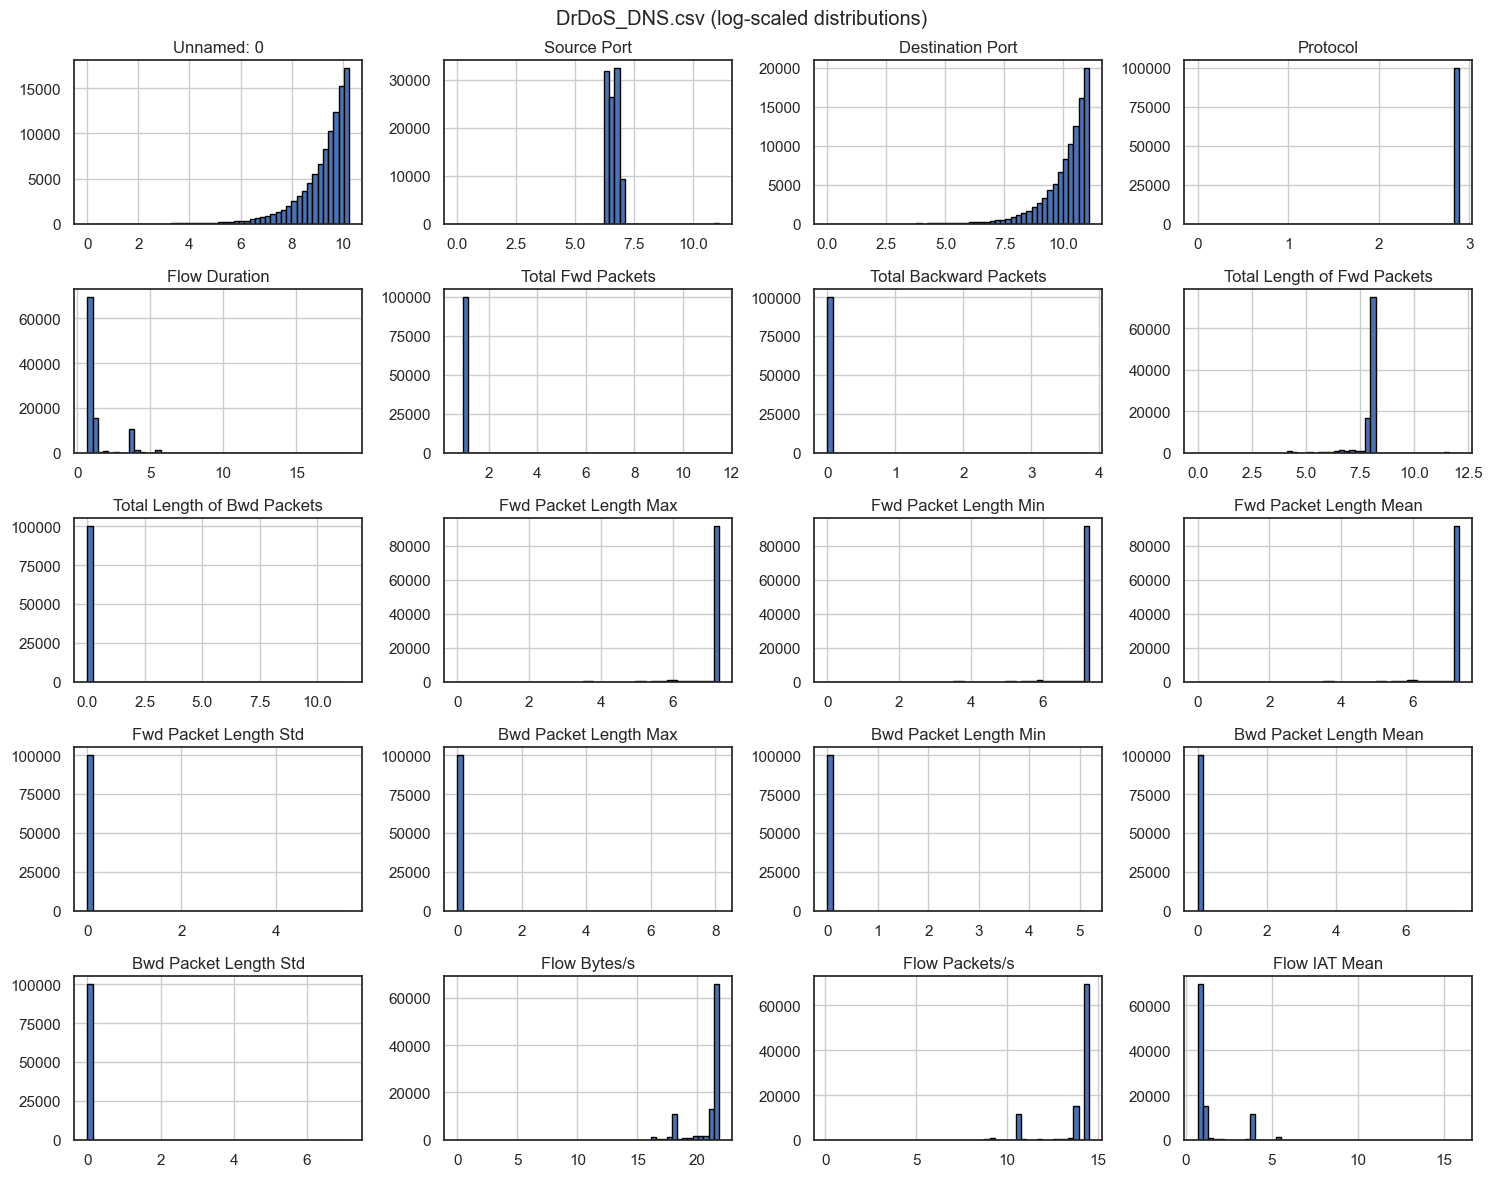

c:\Users\Ale\Documents\NN-Labs\.venv\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\Ale\Documents\NN-Labs\.venv\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


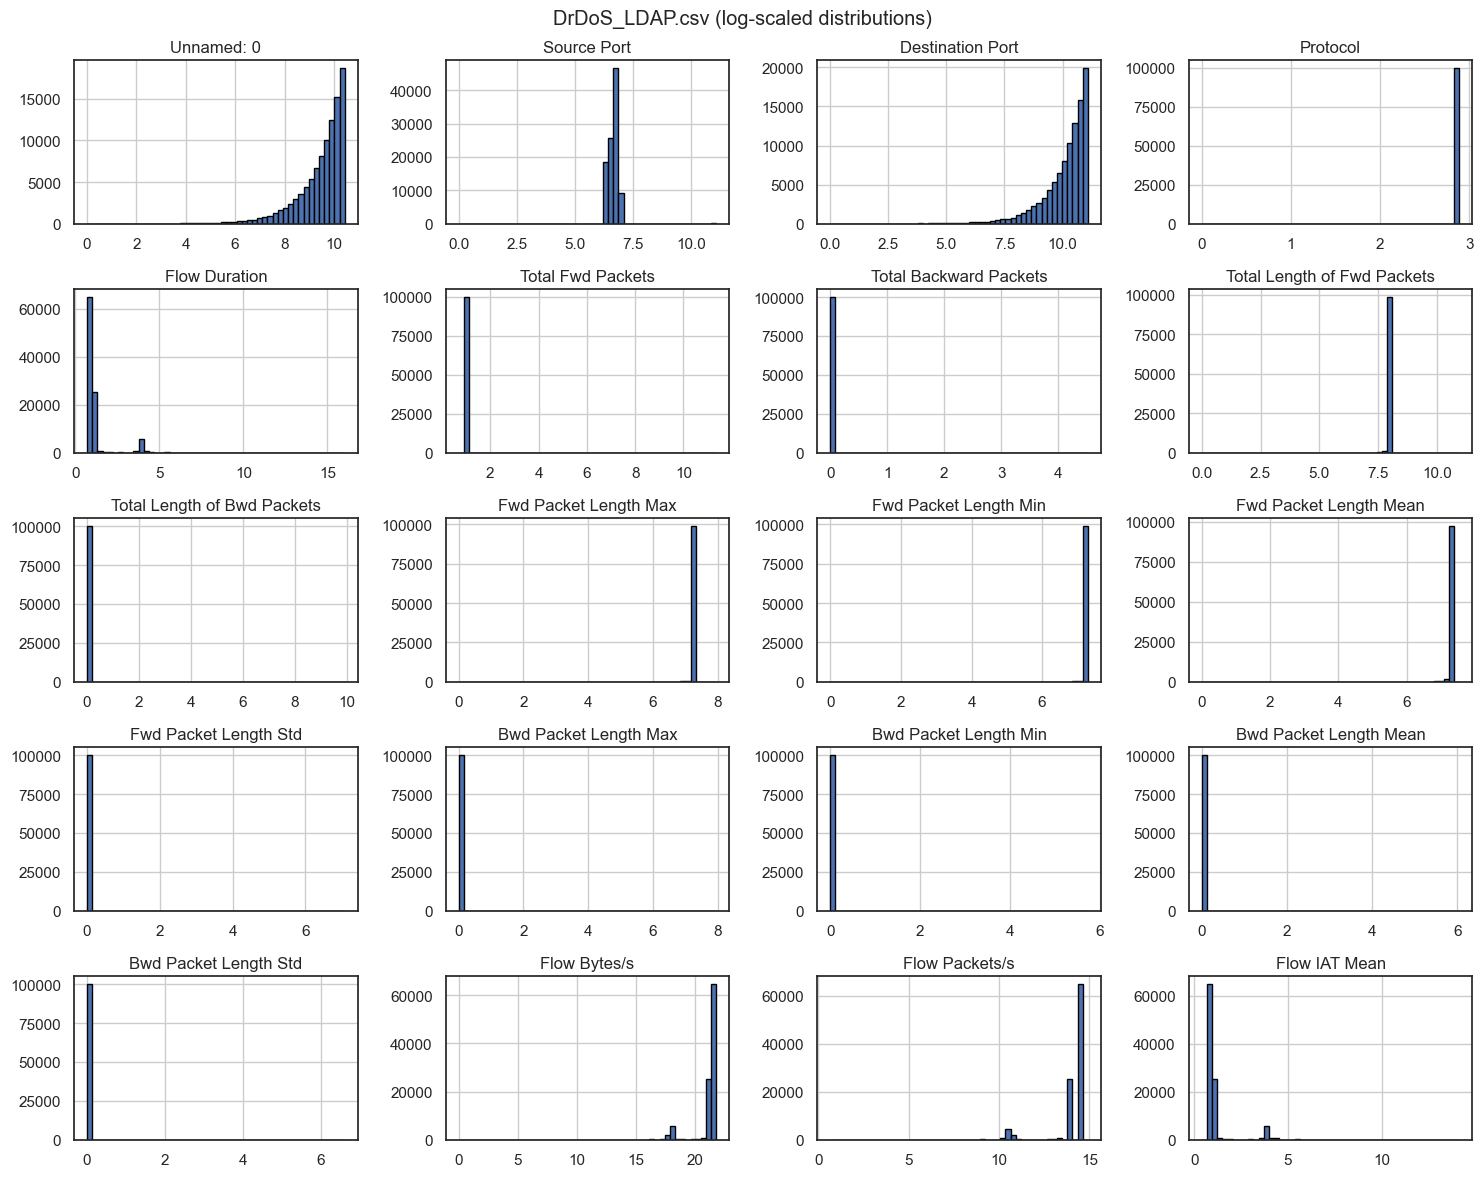

c:\Users\Ale\Documents\NN-Labs\.venv\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\Ale\Documents\NN-Labs\.venv\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


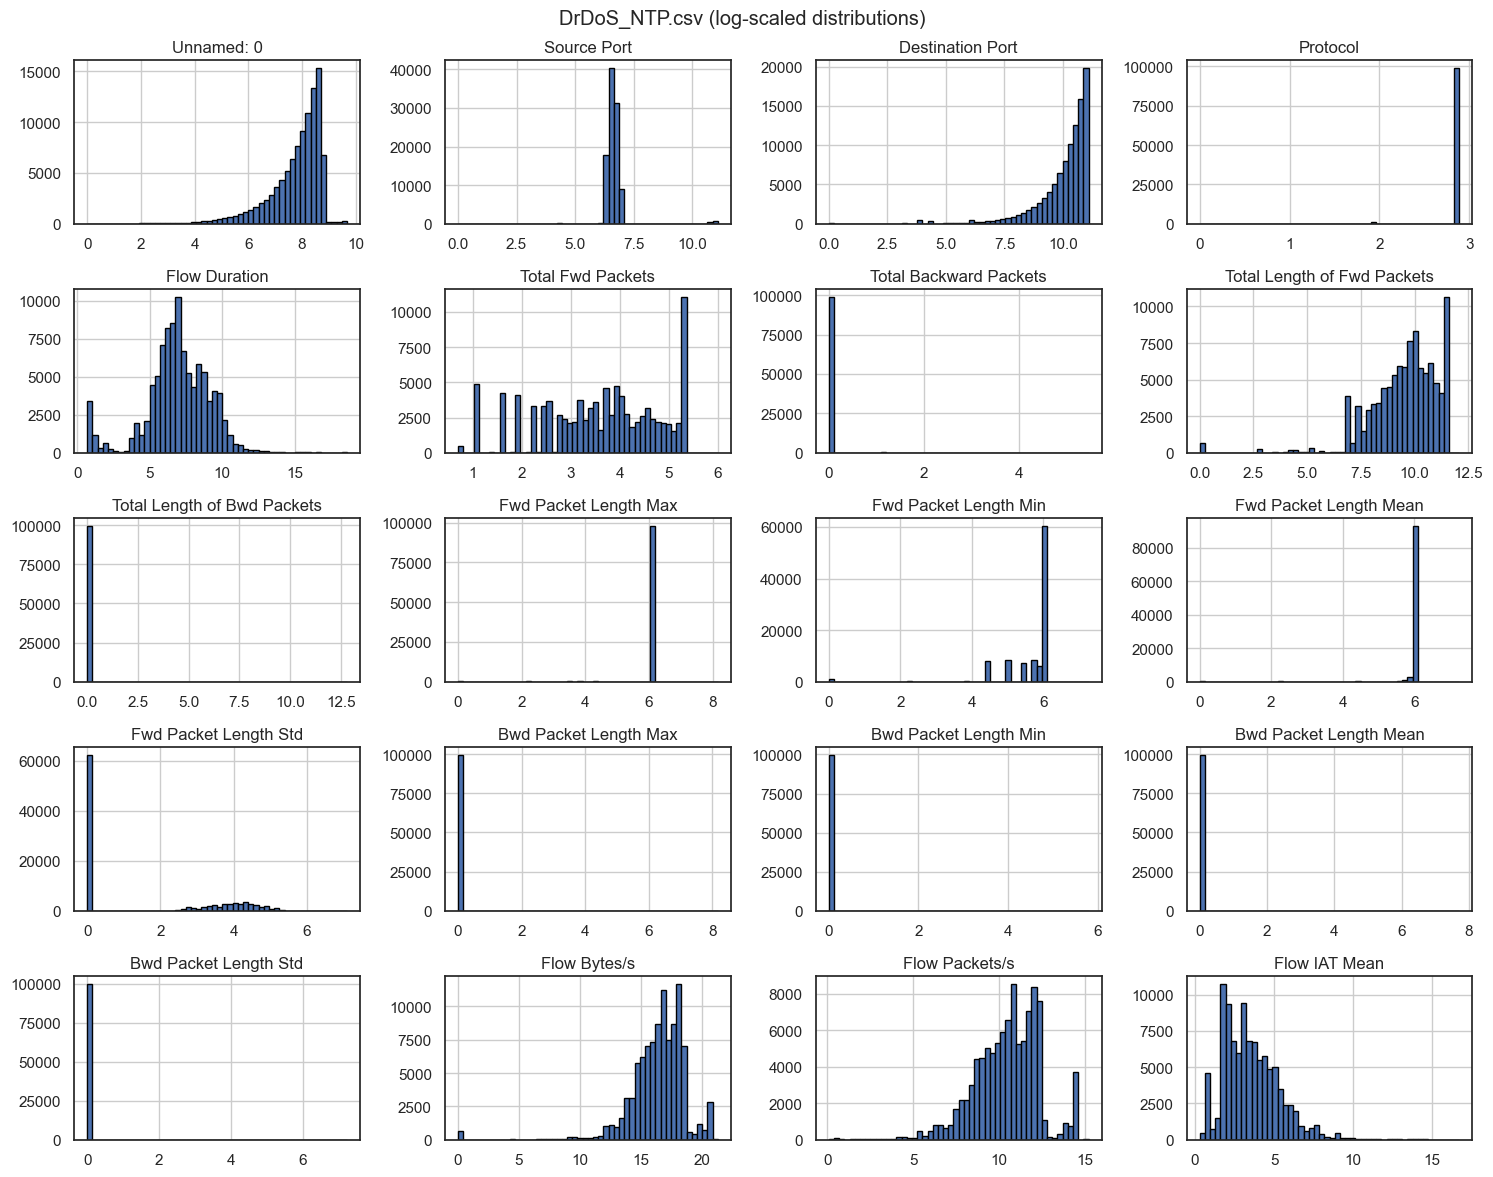

c:\Users\Ale\Documents\NN-Labs\.venv\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


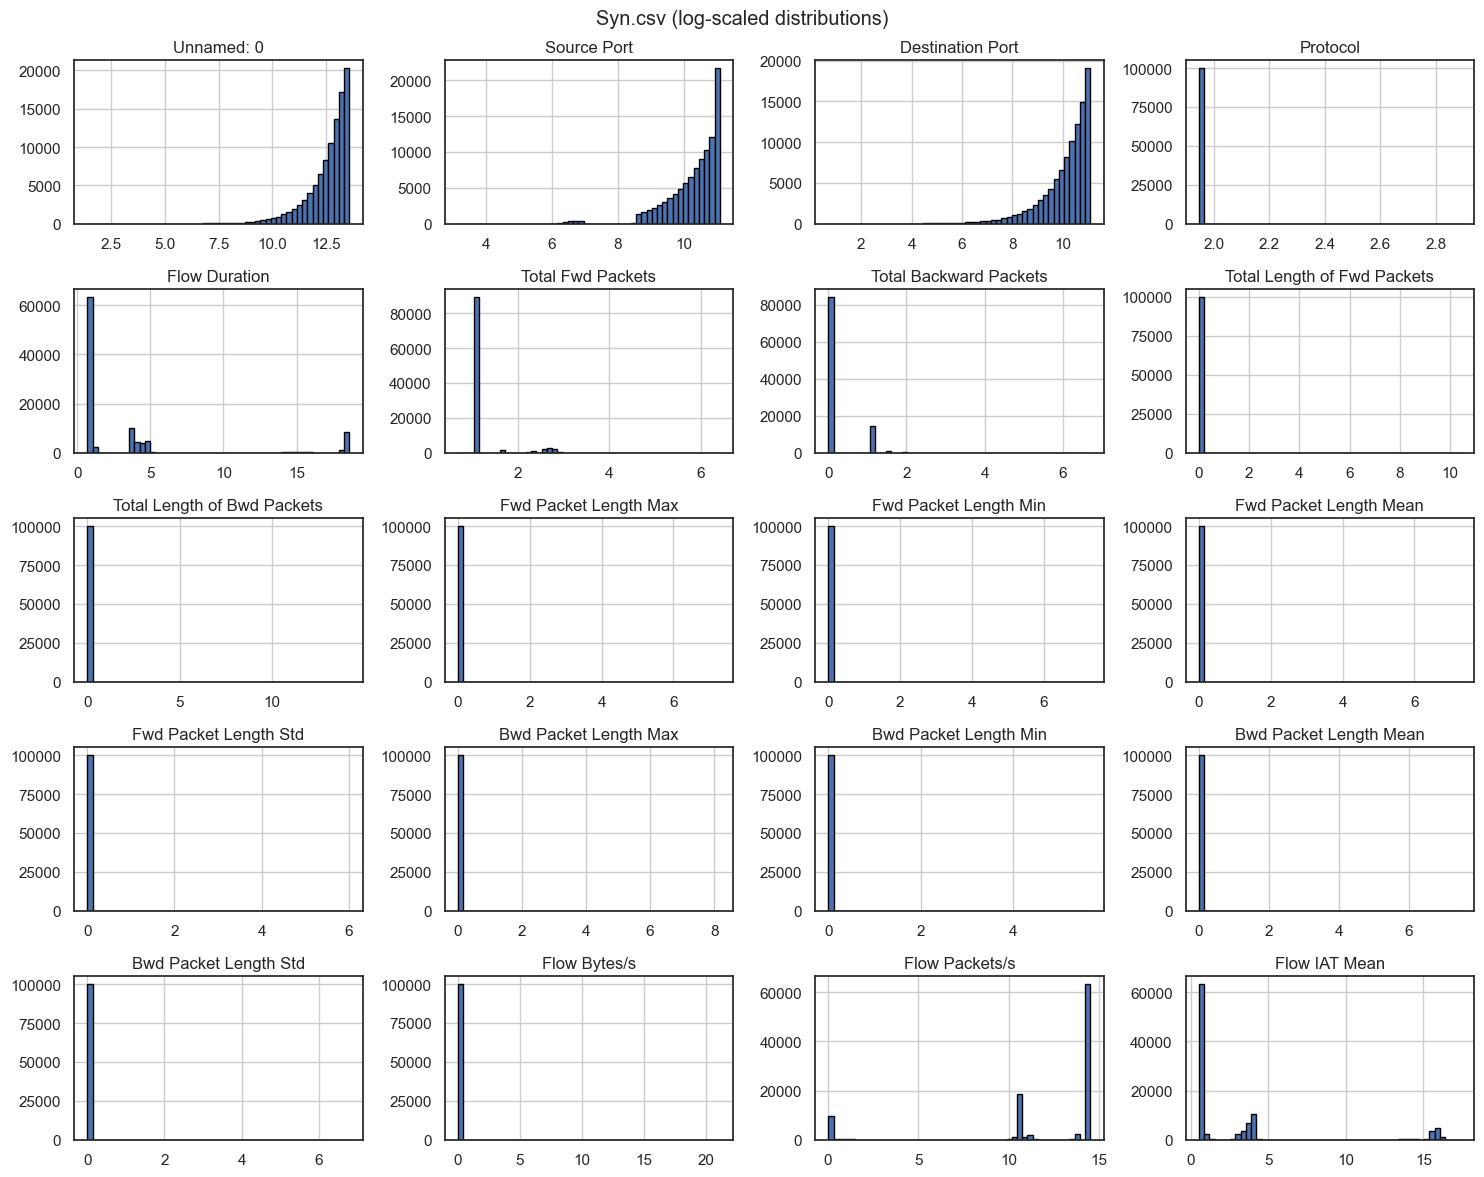

In [ ]:
for name, df in dfs.items():
    sample = df.sample(min(len(df), 100000)).copy()

    # clean invalid values
    sample.replace([np.inf, -np.inf], np.nan, inplace=True)
    sample.dropna(inplace=True)
    numeric = sample.select_dtypes(include="number")
    numeric = numeric.apply(lambda x: np.log1p(x))

    # plot only first 20 features per dataset
    cols = numeric.columns[:20]

    numeric[cols].hist(
        figsize=(15,12),
        bins=50,
        edgecolor="black"
    )

    plt.suptitle(f"{name} (log-scaled distributions)")
    plt.tight_layout()
    plt.show()

### **1.7 Correlation Heatmap**

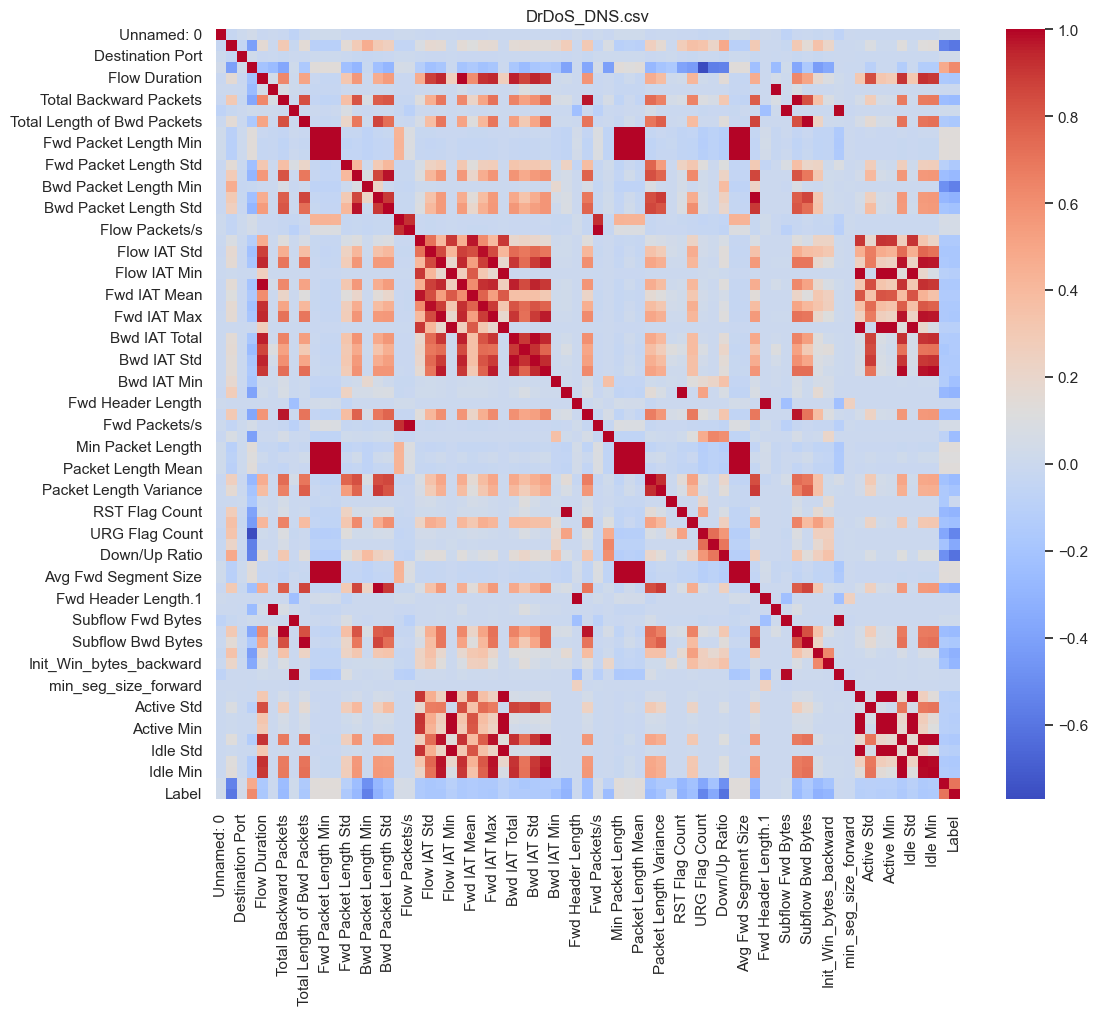

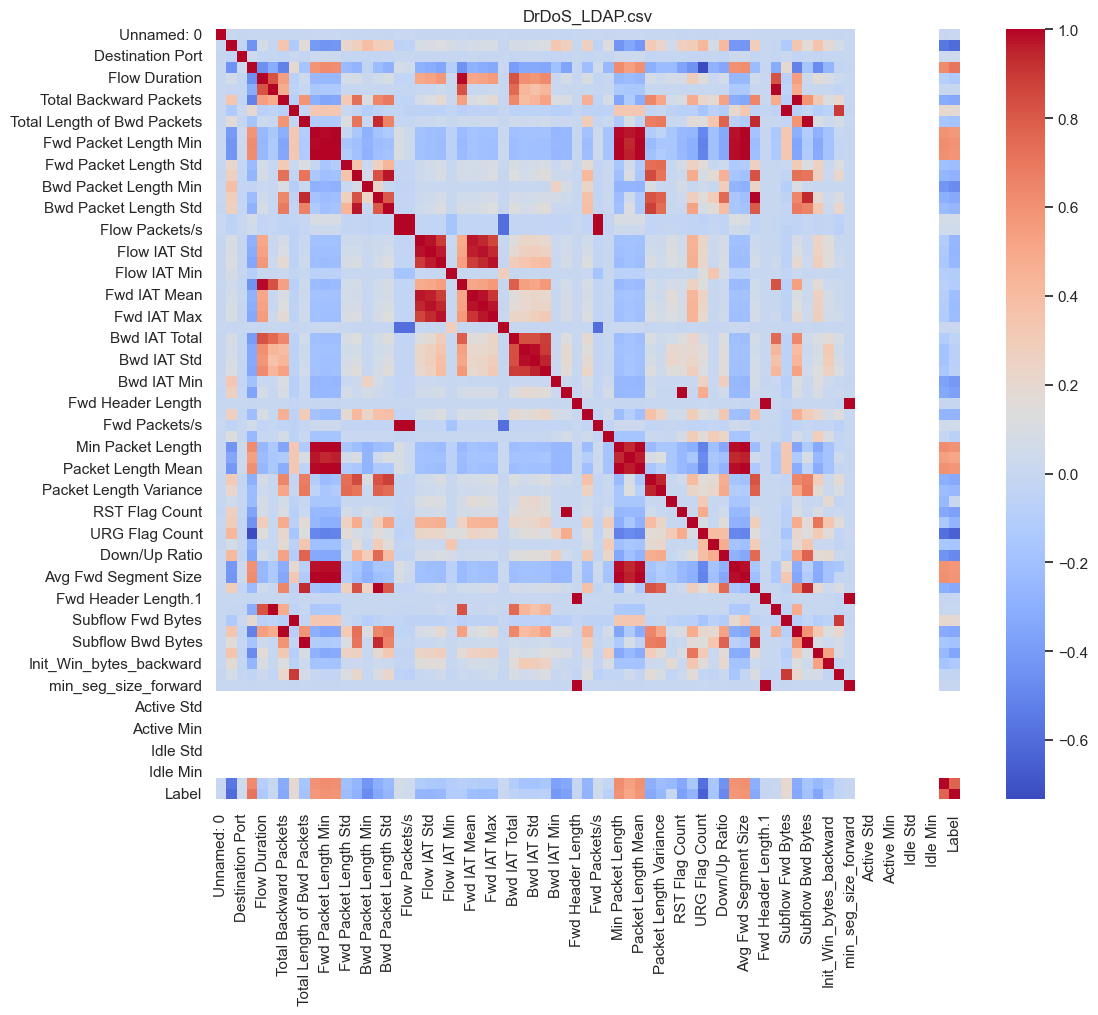

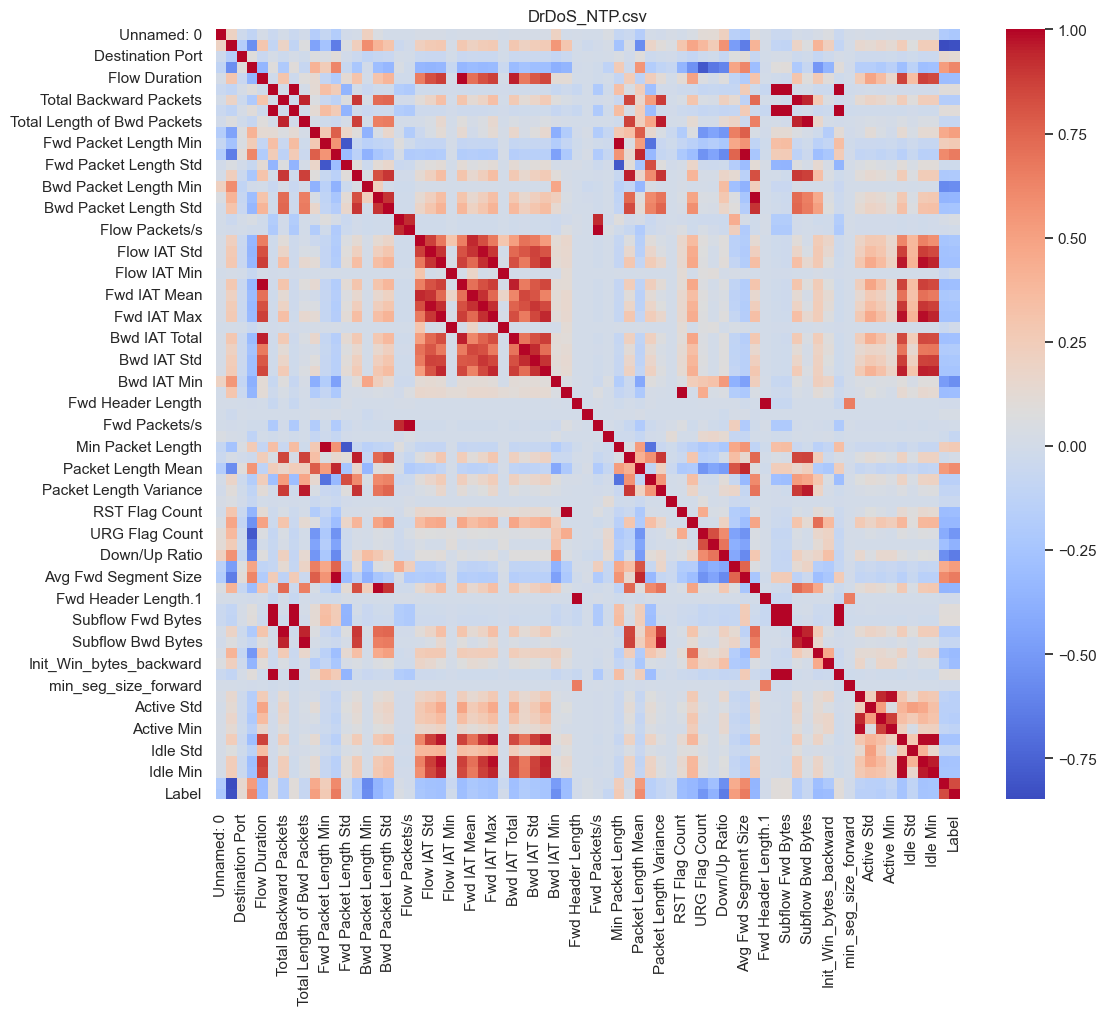

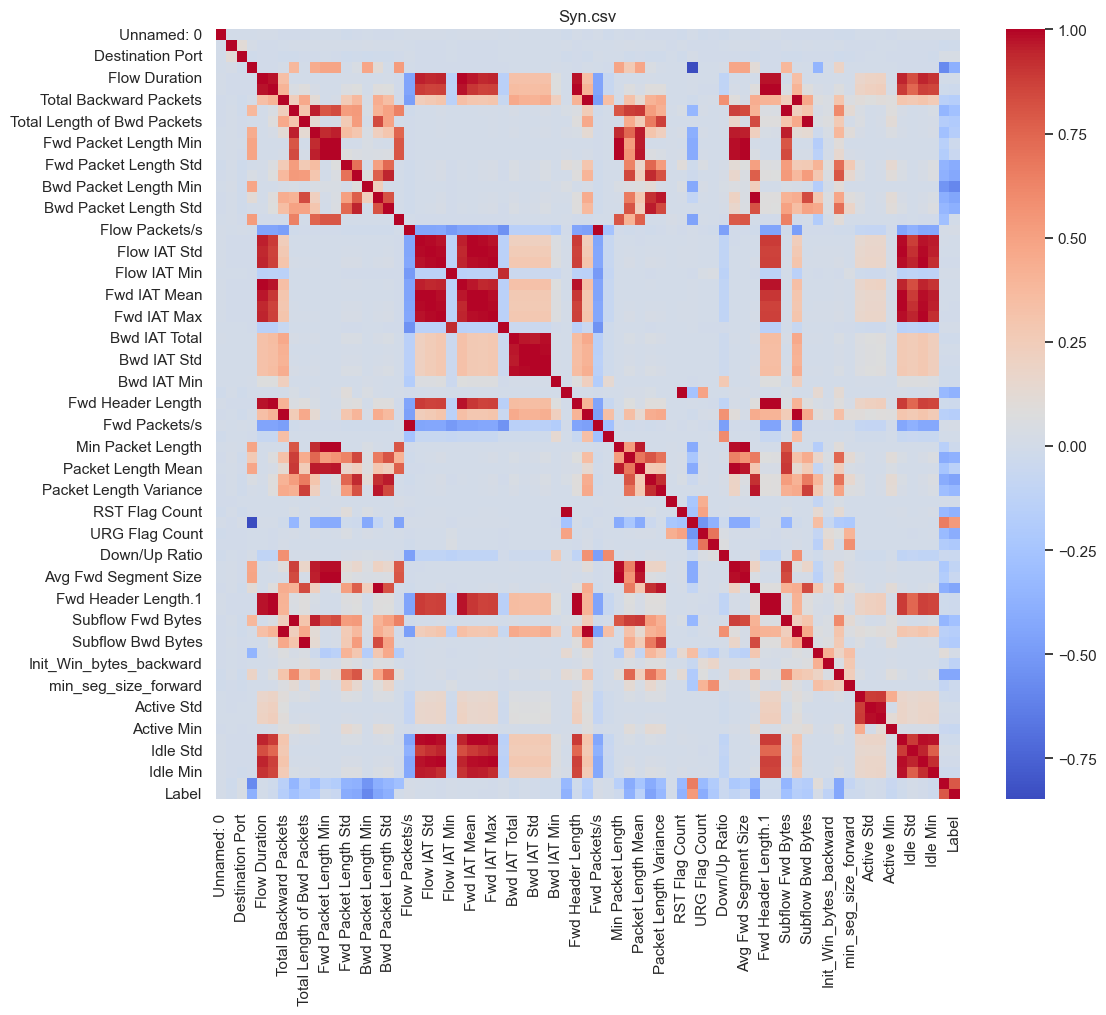

In [35]:
for name, df in dfs.items():
    sample = df.sample(min(len(df), 100000))
    corr = sample.corr(numeric_only=True)
    plt.figure(figsize=(12,10))
    sns.heatmap(corr, cmap="coolwarm")
    plt.title(name)
    plt.show()

### **1.8 Removing Perfectly Correlated Features**

During the correlation analysis, we observed that some numerical features are **perfectly correlated** with others (correlation coefficient = **1 or -1**).  
Perfect correlation indicates that two features contain **exactly the same information**, meaning one of them is redundant.

To address this issue while avoiding the removal of useful information, the following procedure was applied:

1. **Compute the correlation matrix** for each dataset using only numerical features.
2. **Identify columns with perfect correlation** (|correlation| = 1) using the upper triangle of the correlation matrix.  
   This ensures that only **duplicate features** are detected.
3. **Store the redundant columns for each dataset separately.**
4. **Compute the intersection of redundant columns across all datasets.**  
   This step guarantees that a column is removed **only if it is perfectly redundant in every dataset**, preventing the accidental removal of features that may be informative for a specific attack type.
5. **Drop the redundant columns** from all datasets.



In [36]:
def find_perfect_correlations(dfs: dict[str, pd.DataFrame]):
    redundant_per_dataset = {}
    for name, df in dfs.items():
        numeric_df = df.select_dtypes(include="number")
        corr = numeric_df.corr().abs()
        upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        redundant_cols = set(
            col for col in upper.columns if any(upper[col] == 1)
        )
        redundant_per_dataset[name] = redundant_cols
        print(f"{name} redundant columns:")
        print(redundant_cols)
        print("-"*40)

    common_redundant = set.intersection(*redundant_per_dataset.values())
    print("Columns perfectly correlated in ALL datasets:")
    print(common_redundant)

    return common_redundant

In [37]:
def drop_redundant_columns(dfs: dict[str, pd.DataFrame], cols_to_drop):

    for name, df in dfs.items():
        print(f"Dropping from {name}:")
        print(cols_to_drop)
        dfs[name] = df.drop(columns=cols_to_drop)

    return dfs

In [38]:
common_redundant = find_perfect_correlations(dfs)

DrDoS_DNS.csv redundant columns:
{'Subflow Bwd Bytes', 'Fwd Header Length.1', 'Subflow Fwd Packets', 'Avg Fwd Segment Size', 'RST Flag Count', 'Subflow Bwd Packets', 'Subflow Fwd Bytes'}
----------------------------------------
DrDoS_LDAP.csv redundant columns:
{'Subflow Bwd Bytes', 'Active Min', 'Fwd Header Length.1', 'Subflow Fwd Packets', 'Avg Fwd Segment Size', 'RST Flag Count', 'Idle Min', 'Subflow Bwd Packets', 'Idle Max', 'Avg Bwd Segment Size', 'Subflow Fwd Bytes', 'Active Max'}
----------------------------------------
DrDoS_NTP.csv redundant columns:
{'Subflow Bwd Bytes', 'Fwd Header Length.1', 'Subflow Fwd Packets', 'Avg Fwd Segment Size', 'RST Flag Count', 'Subflow Bwd Packets', 'Avg Bwd Segment Size', 'Subflow Fwd Bytes'}
----------------------------------------
Syn.csv redundant columns:
{'Subflow Bwd Bytes', 'Fwd Header Length.1', 'Subflow Fwd Packets', 'Avg Fwd Segment Size', 'RST Flag Count', 'Subflow Bwd Packets', 'Avg Bwd Segment Size', 'Subflow Fwd Bytes'}
----------

In [39]:
dfs = drop_redundant_columns(dfs, common_redundant)

Dropping from DrDoS_DNS.csv:
{'Subflow Bwd Bytes', 'Fwd Header Length.1', 'Subflow Fwd Packets', 'Avg Fwd Segment Size', 'RST Flag Count', 'Subflow Bwd Packets', 'Subflow Fwd Bytes'}
Dropping from DrDoS_LDAP.csv:
{'Subflow Bwd Bytes', 'Fwd Header Length.1', 'Subflow Fwd Packets', 'Avg Fwd Segment Size', 'RST Flag Count', 'Subflow Bwd Packets', 'Subflow Fwd Bytes'}
Dropping from DrDoS_NTP.csv:
{'Subflow Bwd Bytes', 'Fwd Header Length.1', 'Subflow Fwd Packets', 'Avg Fwd Segment Size', 'RST Flag Count', 'Subflow Bwd Packets', 'Subflow Fwd Bytes'}
Dropping from Syn.csv:
{'Subflow Bwd Bytes', 'Fwd Header Length.1', 'Subflow Fwd Packets', 'Avg Fwd Segment Size', 'RST Flag Count', 'Subflow Bwd Packets', 'Subflow Fwd Bytes'}


### **1.9 Duplicates Rows**



In [40]:
for name, df in dfs.items():
    
    print(name)
    
    duplicates = df.duplicated().sum()
    print("Duplicate rows before dropping:", duplicates)
    
    # Drop duplicates
    dfs[name] = df.drop_duplicates()
    
    duplicates_after = dfs[name].duplicated().sum()
    print("Duplicate rows after dropping:", duplicates_after)
    
    print("-" * 40)

DrDoS_DNS.csv
Duplicate rows before dropping: 571
Duplicate rows after dropping: 0
----------------------------------------
DrDoS_LDAP.csv
Duplicate rows before dropping: 180
Duplicate rows after dropping: 0
----------------------------------------
DrDoS_NTP.csv
Duplicate rows before dropping: 4
Duplicate rows after dropping: 0
----------------------------------------
Syn.csv
Duplicate rows before dropping: 0
Duplicate rows after dropping: 0
----------------------------------------


### **1.10 Label Inconsistencies**
To ensure the reliability of the dataset, we performed a **label consistency check**.  
This analysis verifies whether there are samples that share identical feature values but different labels. Such cases would indicate label conflicts or inconsistencies** in the dataset.

The procedure consisted of grouping rows by all feature columns and counting how many distinct labels appear for each group. If more than one label is associated with the same feature configuration, the sample would be considered inconsistent.

After performing this check across all datasets, **no label conflicts were detected**.  
This indicates that there are **no inconsistent samples** where identical feature values correspond to different labels. No additional preprocessing steps were required to resolve label inconsistencies.

In [41]:
def check_label_conflicts(dfs: dict[str, pd.DataFrame]) -> None:

    for name, df in dfs.items():

        print("="*50)
        print(name)

        feature_cols = df.columns.difference(["Label"])

        conflicts = (
            df.groupby(list(feature_cols))["Label"]
            .nunique()
            .reset_index()
        )

        conflicts = conflicts[conflicts["Label"] > 1]

        print("Conflicting samples:", len(conflicts))

In [42]:
check_label_conflicts(dfs)

DrDoS_DNS.csv
Conflicting samples: 0
DrDoS_LDAP.csv
Conflicting samples: 0
DrDoS_NTP.csv
Conflicting samples: 0
Syn.csv
Conflicting samples: 0


### **1.11 Export clean .csv files**


In [43]:
def save_dfs(dfs: dict[str, pd.DataFrame], output_directory: str) -> None:

    if not os.path.exists(output_directory):
        os.makedirs(output_directory)

    for name, df in dfs.items():

        output_file = os.path.join(
            output_directory,
            name.replace(".csv", "_clean.csv")
        )

        df.to_csv(output_file, index=False)

        print(f"Saved → {output_file}")

    print("-" * 40)
    print(f"{len(dfs)} file(s) saved.")

In [45]:
dfs_cleaned = save_dfs(dfs, OUTPUT_PATH)


Saved → clean_data/DrDoS_DNS_clean.csv
Saved → clean_data/DrDoS_LDAP_clean.csv
Saved → clean_data/DrDoS_NTP_clean.csv
Saved → clean_data/Syn_clean.csv
----------------------------------------
4 file(s) saved.
